In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("coref_utterances.csv")

In [3]:
df

,utterance_id,segmentation_uuid,utterance_text,utterance_coref,episode,podcast,BBA,BBAC,diff
0,1966136,c2f44810-f678-11ed-b34f-00155d6c4ae1,It's not clear they were there a day or two or...,It's not clear 47 percent were there a day or ...,"Big Free Speech Victory, plus IRS GROWING by 3...",Verdict with Ted Cruz,0.043077,0.957738,-0.914661
1,1962362,b425077a-f678-11ed-b7cb-00155d6c4ae1,"Is there any downside to Bragg doing this, Sen...",Is there any downside to a left-wing partisan ...,Trump Indictment - What It Means & What's Next,Verdict with Ted Cruz,0.050202,0.964221,-0.914020
2,2018001,82c56fd4-f679-11ed-a350-00155d6c4ae1,"Okay, in just one second, we'll get to Preside...","Okay, in just one second, we'll get to Donald.",Ep. 1724 - Tucker's Back!,The Ben Shapiro Show,0.962666,0.049172,0.913494
3,2106105,c2baaa0e-f67a-11ed-98c2-00155d6c4ae1,That may be a little more nervous than the hon...,the 60 percent saying he's not may be a little...,Tucker’s War With Fox,Pod Save America,0.043361,0.954792,-0.911432
4,2141671,aa32d3b6-f67b-11ed-9b0c-00155d6c4ae1,There's no ambiguity here as to what he stands...,There's no ambiguity here as to what Mauricio ...,The Blood-Dimmed Tide,Gaslit Nation with Andrea Chalupa and Sarah Ke...,0.032293,0.939736,-0.907444
...,...,...,...,...,...,...,...,...,...
89447,1990802,192a0634-f679-11ed-b01d-00155d6c4ae1,♪♪,♪,Dr. Noam Sobel: How Smells Influence Our Hormo...,Huberman Lab,0.190749,0.190749,0.000000
89448,2019911,86c5c142-f679-11ed-8ad2-00155d6c4ae1,♪♪,♪,"Ep. 1722 - Don't Believe The Media, Listen To ...",The Ben Shapiro Show,0.190754,0.190754,0.000000
89449,1988460,130a764e-f679-11ed-bd03-00155d6c4ae1,♪♪,♪,Science-Based Mental Training & Visualization ...,Huberman Lab,0.190749,0.190749,0.000000
89450,2141885,ab6abc6c-f67b-11ed-8f77-00155d6c4ae1,♪♪,♪,Teaser - Jeff Sharlet Takes the Gaslit Nation ...,Gaslit Nation with Andrea Chalupa and Sarah Ke...,0.190754,0.190754,0.000000


In [4]:
import regex as re
# calculate improvement in checkworthiness score from coref
df["diff"] = df["BBAC"] - df["BBA"]
# normalize the text in utterance_text and utterance_coref fields to remove punctuation (periods, commas, quotes, etc.), capitalization or any special characters (e.g. emojis and ♪)
df["utterance_text_norm"] = df["utterance_text"].str.lower().apply(lambda x: re.sub('[^\p{L}\p{N}\s]', '', x)).str.strip()
df["utterance_coref_norm"] = df["utterance_coref"].str.lower().apply(lambda x: re.sub('[^\p{L}\p{N}\s]', '', x)).str.strip()


In [5]:
# filter to remove any rows where utterance_text_norm and utterance_coref_norm contain the same string
df_unique = df[df["utterance_text_norm"] != df["utterance_coref_norm"]]


In [25]:
df_unique

,utterance_id,segmentation_uuid,utterance_text,utterance_coref,episode,podcast,BBA,BBAC,diff,utterance_text_norm,utterance_coref_norm
0,1966136,c2f44810-f678-11ed-b34f-00155d6c4ae1,It's not clear they were there a day or two or...,It's not clear 47 percent were there a day or ...,"Big Free Speech Victory, plus IRS GROWING by 3...",Verdict with Ted Cruz,0.043077,0.957738,0.914661,its not clear they were there a day or two or ...,its not clear 47 percent were there a day or t...
1,1962362,b425077a-f678-11ed-b7cb-00155d6c4ae1,"Is there any downside to Bragg doing this, Sen...",Is there any downside to a left-wing partisan ...,Trump Indictment - What It Means & What's Next,Verdict with Ted Cruz,0.050202,0.964221,0.914020,is there any downside to bragg doing this senator,is there any downside to a leftwing partisan d...
2,2018001,82c56fd4-f679-11ed-a350-00155d6c4ae1,"Okay, in just one second, we'll get to Preside...","Okay, in just one second, we'll get to Donald.",Ep. 1724 - Tucker's Back!,The Ben Shapiro Show,0.962666,0.049172,-0.913494,okay in just one second well get to president ...,okay in just one second well get to donald
3,2106105,c2baaa0e-f67a-11ed-98c2-00155d6c4ae1,That may be a little more nervous than the hon...,the 60 percent saying he's not may be a little...,Tucker’s War With Fox,Pod Save America,0.043361,0.954792,0.911432,that may be a little more nervous than the hon...,the 60 percent saying hes not may be a little ...
4,2141671,aa32d3b6-f67b-11ed-9b0c-00155d6c4ae1,There's no ambiguity here as to what he stands...,There's no ambiguity here as to what Mauricio ...,The Blood-Dimmed Tide,Gaslit Nation with Andrea Chalupa and Sarah Ke...,0.032293,0.939736,0.907444,theres no ambiguity here as to what he stands for,theres no ambiguity here as to what mauricio g...
...,...,...,...,...,...,...,...,...,...,...,...
89436,2064861,20b00fe2-f67a-11ed-b9c6-00155d6c4ae1,"You know, I can understand why dominion would ...","You know, I can understand why dominion would ...","Tucker Carlson vs. Fox News Legal Battle, and ...",The Megyn Kelly Show,0.636935,0.636935,0.000000,you know i can understand why dominion would d...,you know i can understand why dominion would d...
89437,2043473,d923e7f2-f679-11ed-b746-00155d6c4ae1,"You know, the black children of America suffer...","You know, the black children of America's suff...","Bud Light Backlash Grows, Mr. Beast Fallout, a...",The Megyn Kelly Show,0.028598,0.028598,0.000000,you know the black children of america suffere...,you know the black children of americas suffer...
89438,2011962,6ae3fa0c-f679-11ed-a9ba-00155d6c4ae1,You'll get instant access to the entire DailyW...,You'll get instant access to the entire DailyW...,Ep. 1716 - Visual PROOF Press Is In Biden's Po...,The Ben Shapiro Show,0.250664,0.250664,0.000000,youll get instant access to the entire dailywa...,youll get instant access to the entire dailywa...
89439,2025492,9bc148f0-f679-11ed-ba0f-00155d6c4ae1,You'll receive an early bird discount of 35% o...,You'll receive an early bird discount of 35% o...,Ep. 1730 - Harry And Meghan’s Jussie Smollett ...,The Ben Shapiro Show,0.710709,0.710709,0.000000,youll receive an early bird discount of 35 off...,youll receive an early bird discount of 35 off...


<Axes: >

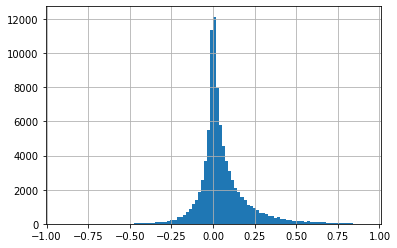

In [6]:
# make a normalized histogram of the diff column
df_unique["diff"].hist(bins=100, )

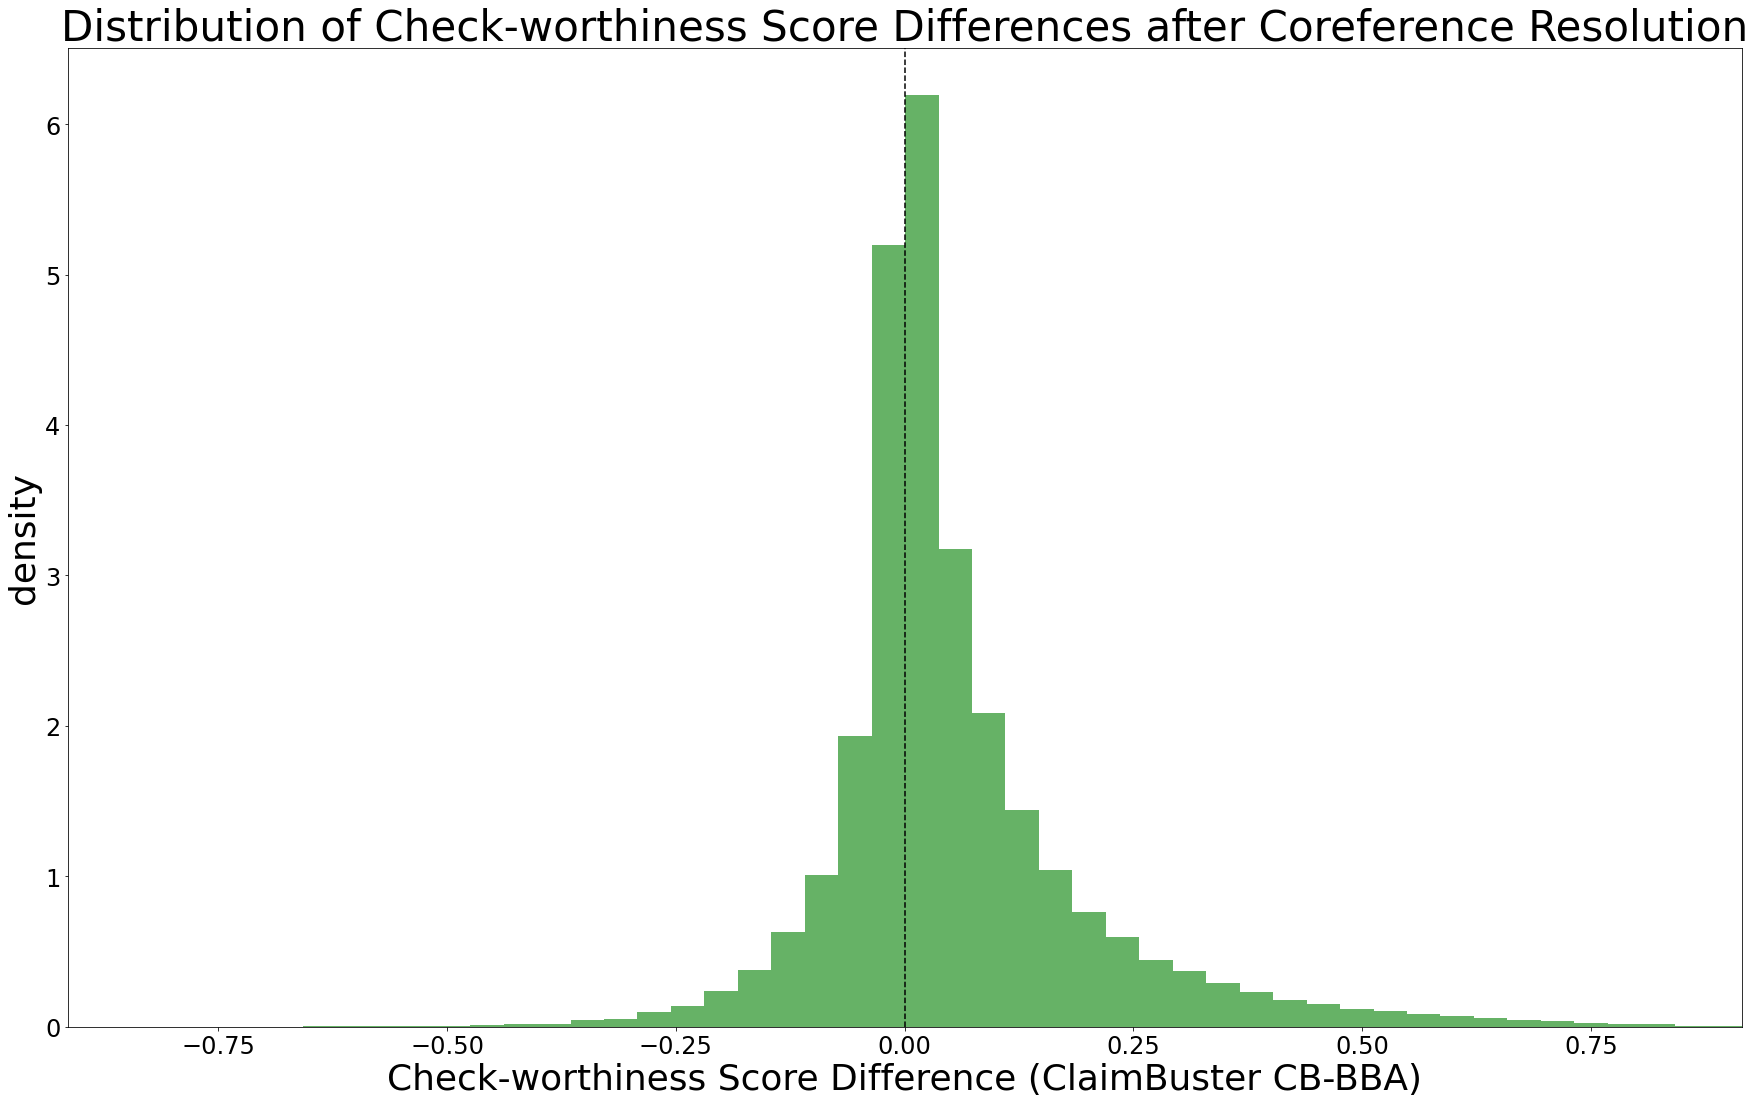

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(30,18))  # set the size of the plot
plt.hist(df_unique['diff'], bins=50, density=True, alpha=0.6, color='g')  # plot a histogram

# set x-axis limits
abs_max = np.max(np.abs(df_unique['diff']))  # get the absolute max of the diff column
plt.xlim([-abs_max, abs_max])  # set x-axis limits to be symmetrical around 0

# add title and labels
plt.title('Distribution of Check-worthiness Score Differences after Coreference Resolution', fontsize=42)
plt.xlabel('Check-worthiness Score Difference (ClaimBuster CB-BBA)', fontsize=36)
plt.ylabel('density', fontsize=36)

# increase the size of the axis labels
plt.tick_params(axis='both', which='major', labelsize=24)

# add a vertical line at 0
plt.axvline(x=0, color='k', linestyle='--')
plt.show()  # display the plot


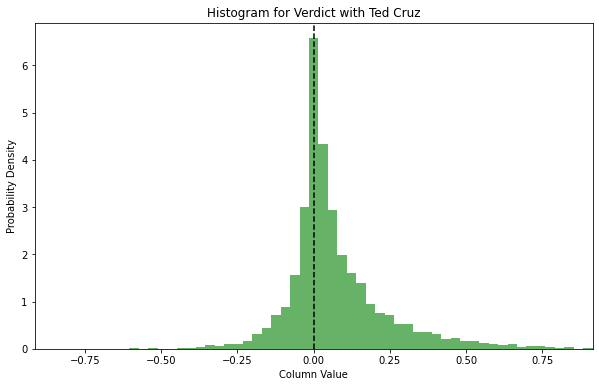

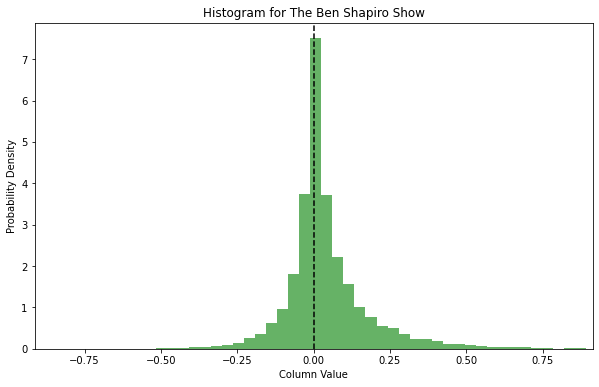

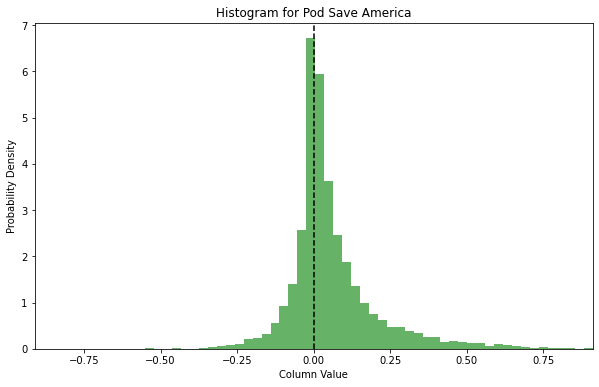

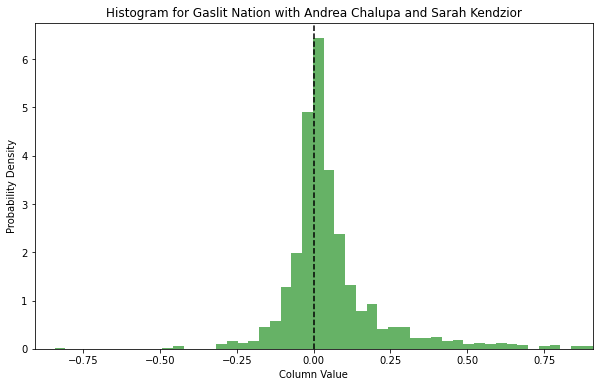

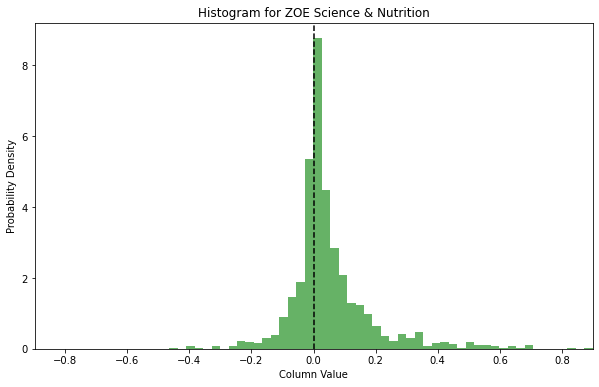

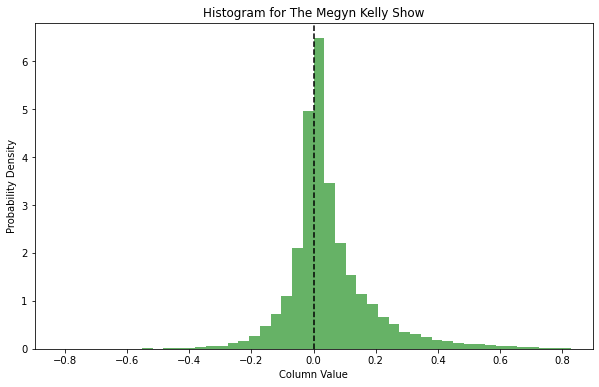

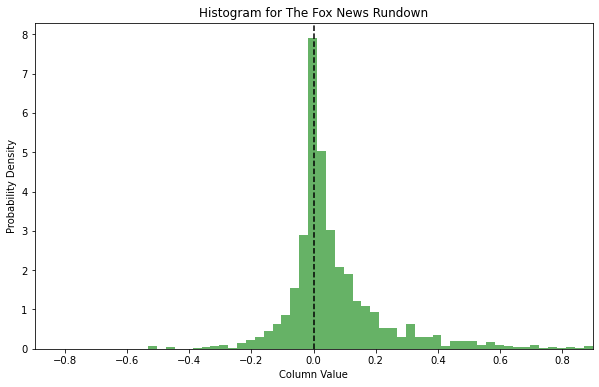

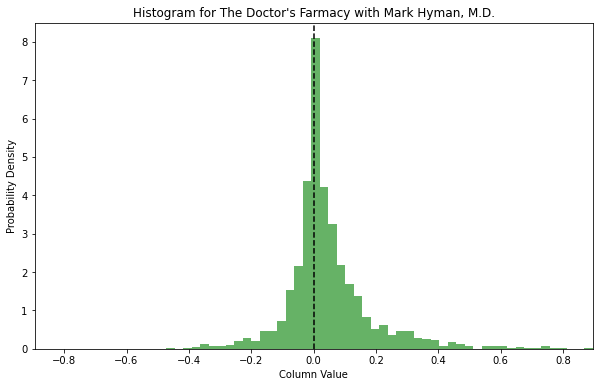

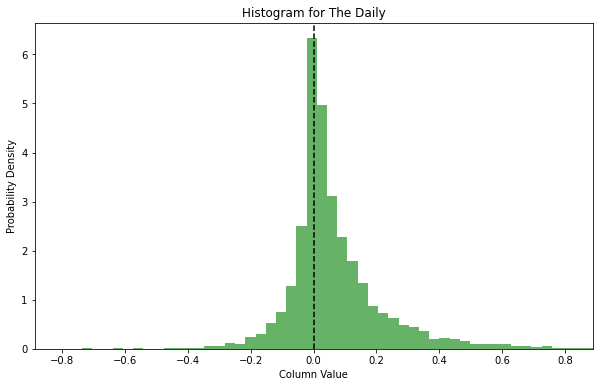

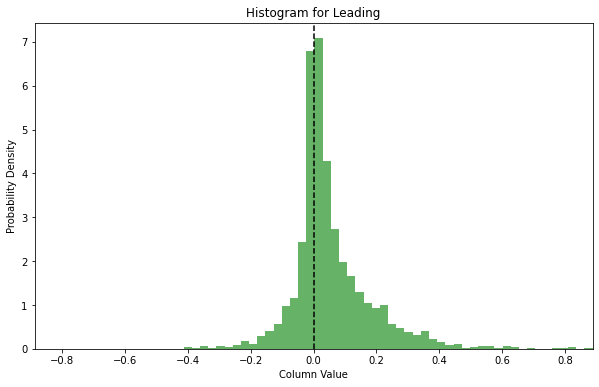

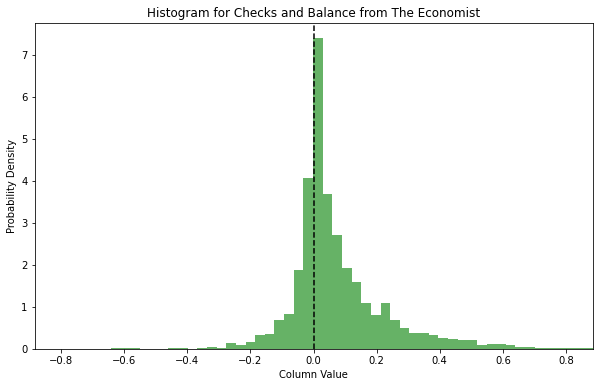

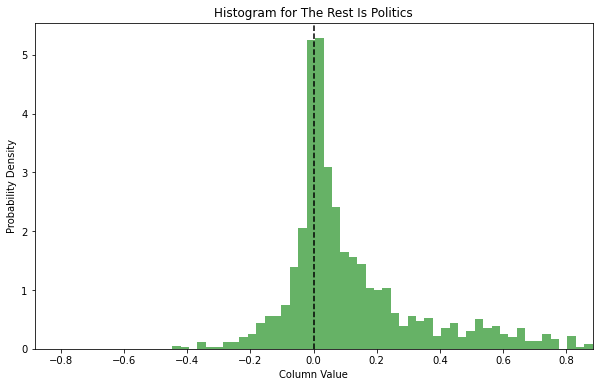

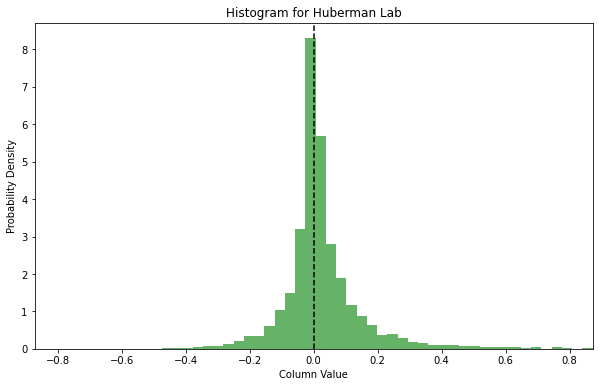

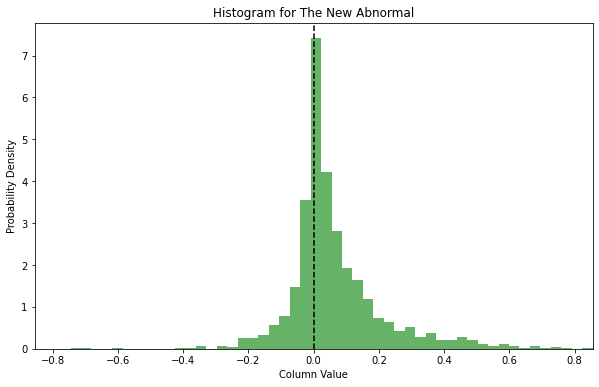

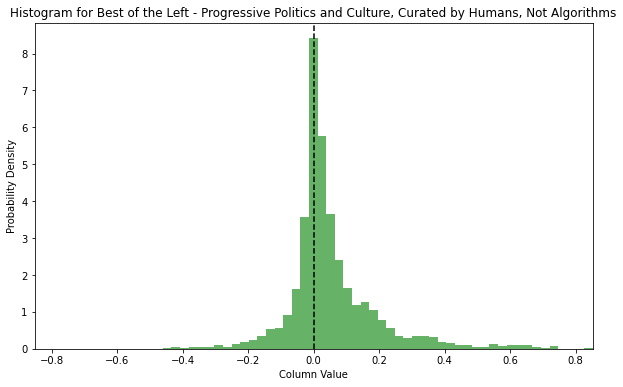

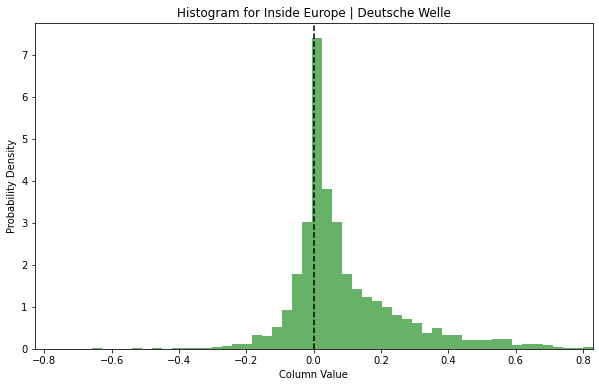

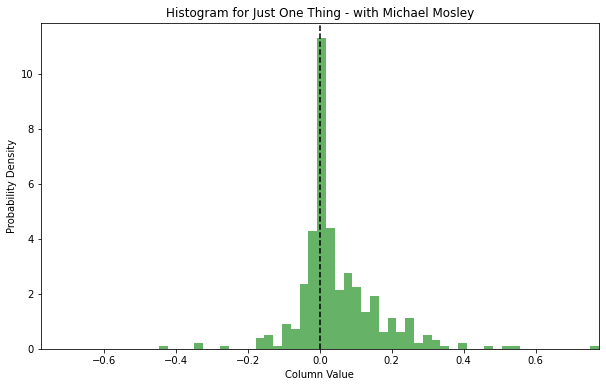

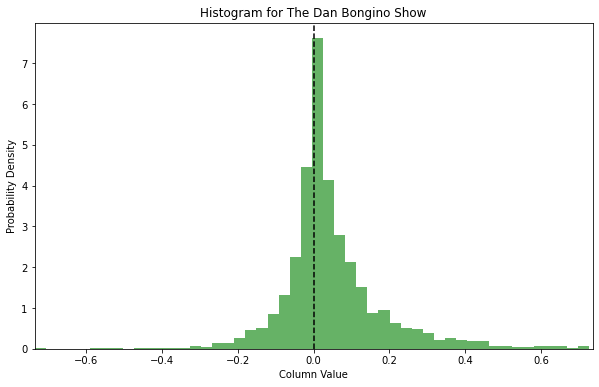

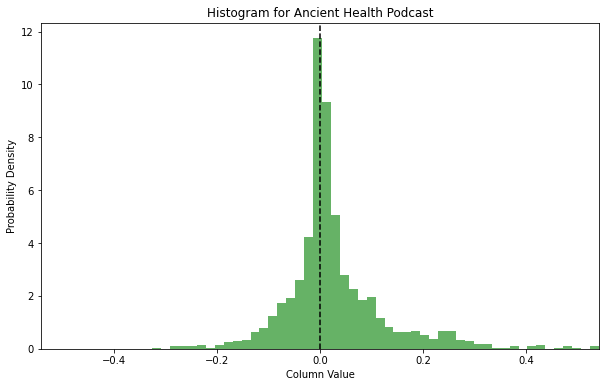

In [12]:
import numpy as np

# get the unique values of the podcast column
podcasts = df_unique["podcast"].unique()

# iterate over the podcasts
for i, podcast in enumerate(podcasts):
    # filter the dataframe to only rows with the current podcast
    df_filt = df_unique[df_unique["podcast"] == podcast]
    # plot a histogram of the diff column
    plt.figure(figsize=(10,6))  # set the size of the plot
    plt.hist(df_filt['diff'], bins=50, density=True, alpha=0.6, color='g')  # plot a histogram
    
    # set x-axis limits
    abs_max = np.max(np.abs(df_filt['diff']))  # get the absolute max of the diff column
    plt.xlim([-abs_max, abs_max])  # set x-axis limits to be symmetrical around 0

    # add title and labels
    plt.title('Histogram for ' + podcast)
    plt.xlabel('Column Value')
    plt.ylabel('Probability Density')

    # add a vertical line at 0
    plt.axvline(x=0, color='k', linestyle='--')
    plt.show()  # display the plot


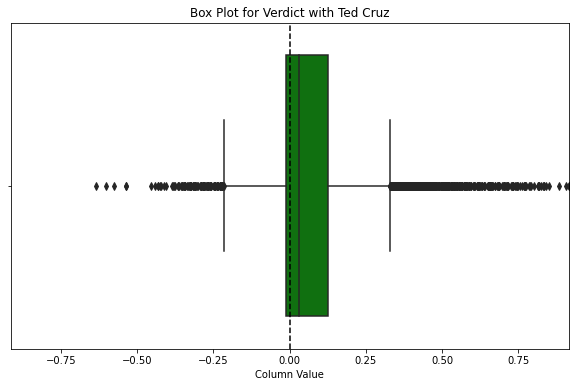

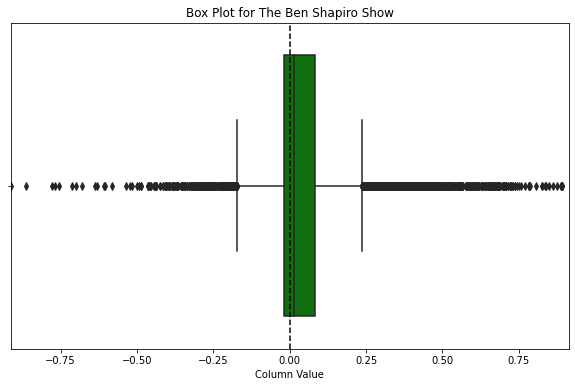

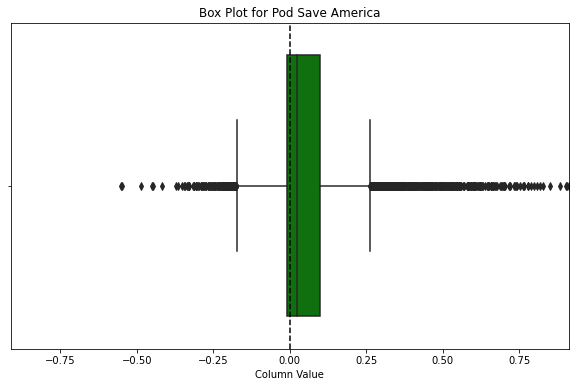

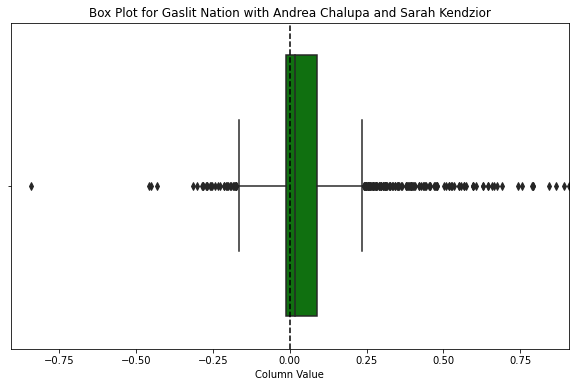

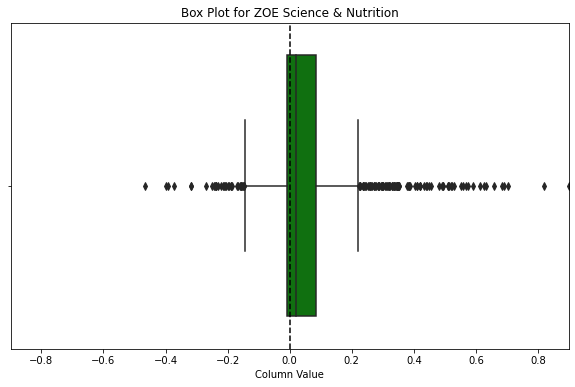

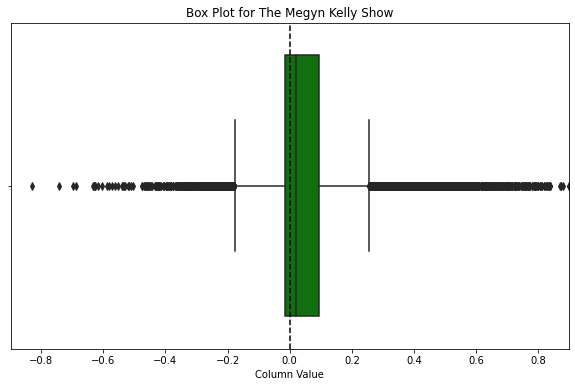

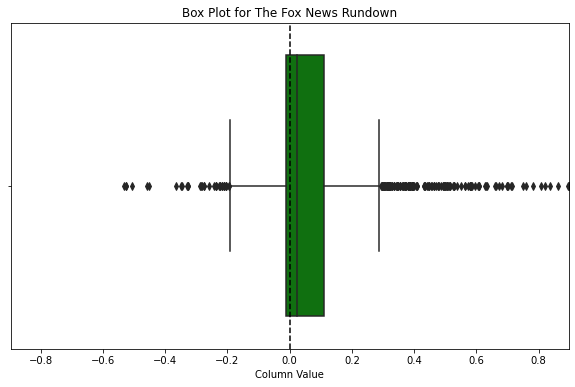

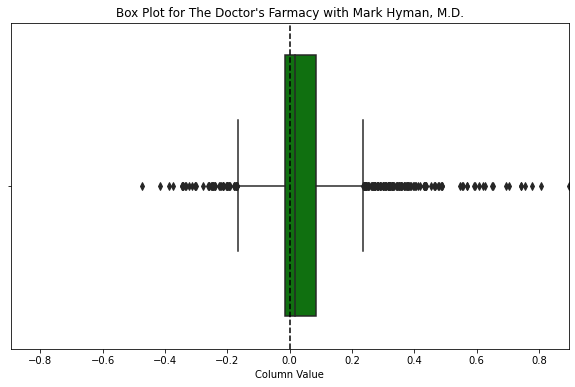

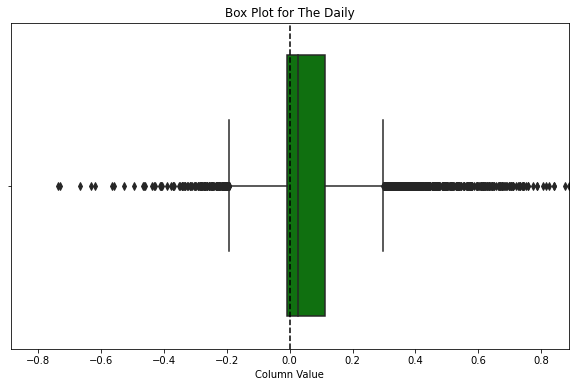

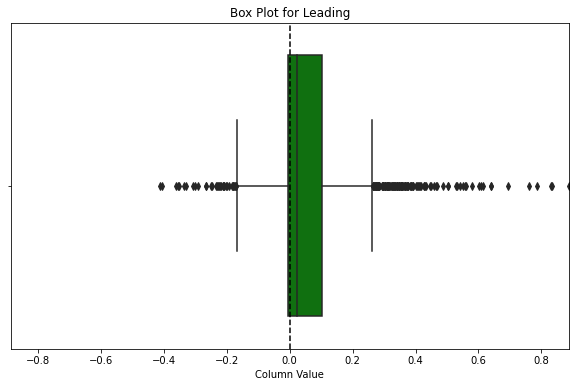

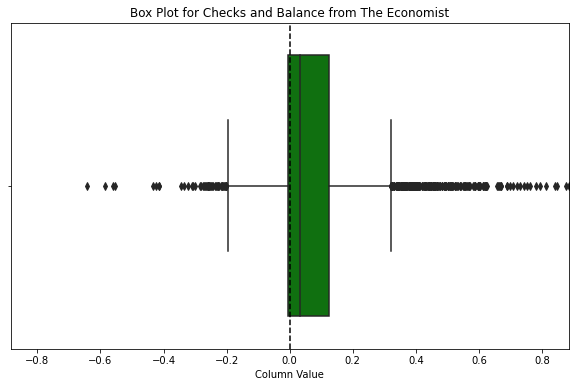

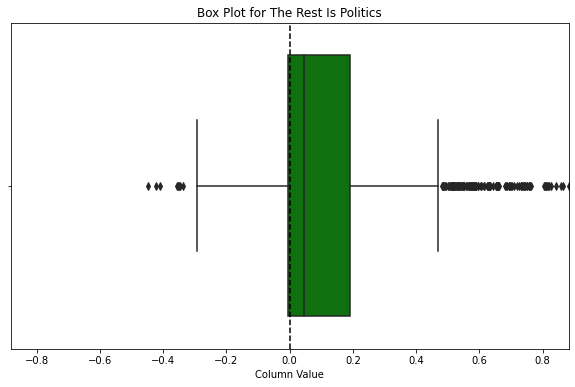

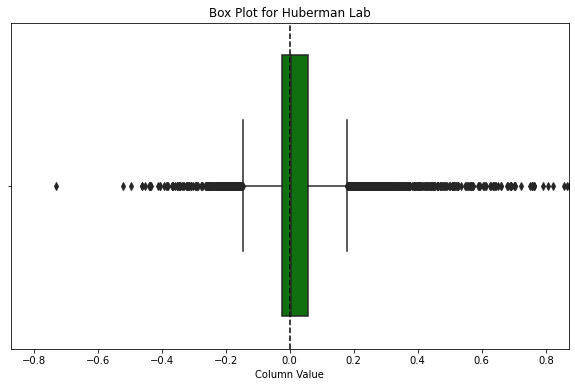

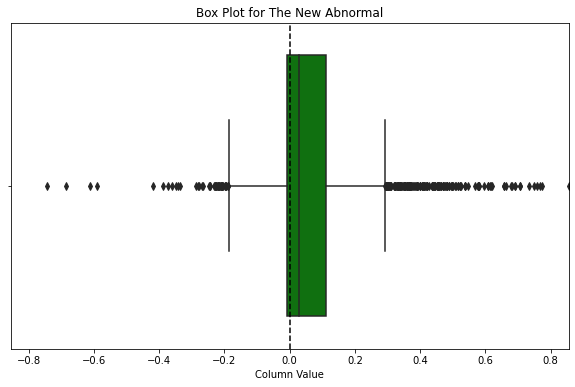

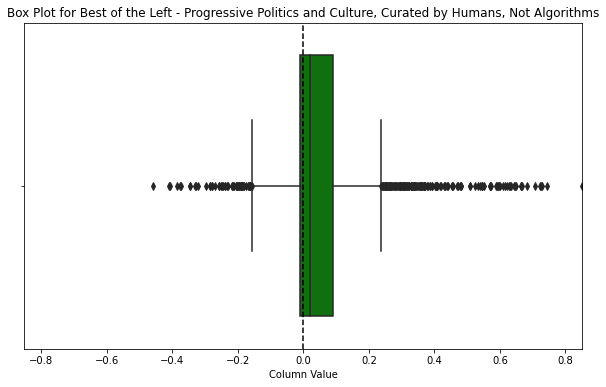

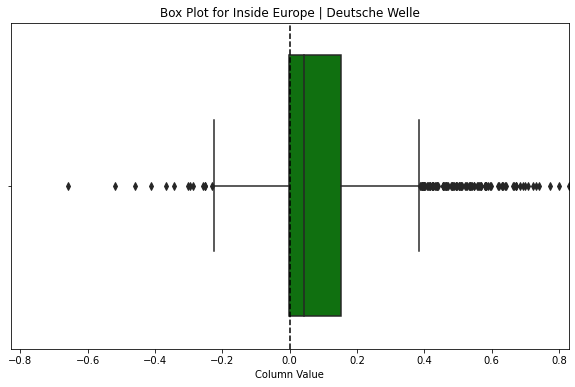

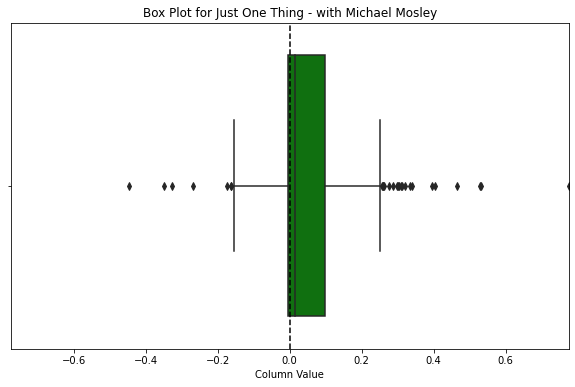

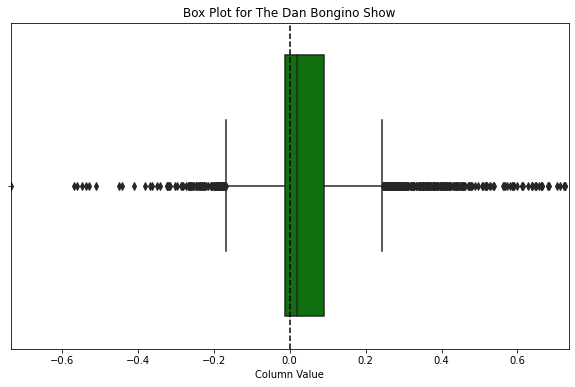

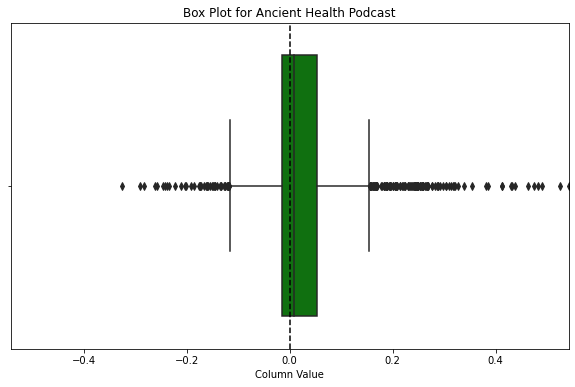

In [43]:
import seaborn as sns

# get the unique values of the podcast column
podcasts = df_unique["podcast"].unique()

# iterate over the podcasts
for i, podcast in enumerate(podcasts):
    # filter the dataframe to only rows with the current podcast
    df_filt = df_unique[df_unique["podcast"] == podcast]
    # create a box plot of the diff column
    plt.figure(figsize=(10,6))  # set the size of the plot
    sns.boxplot(x=df_filt['diff'], color='g')  # create a box plot

        
    # set x-axis limits
    abs_max = np.max(np.abs(df_filt['diff']))  # get the absolute max of the diff column
    plt.xlim([-abs_max, abs_max])  # set x-axis limits to be symmetrical around 0
    
    # add title and labels
    plt.title('Box Plot for ' + podcast)
    plt.xlabel('Column Value')

    # add a vertical line at 0
    plt.axvline(x=0, color='k', linestyle='--')
    plt.show()  # display the plot


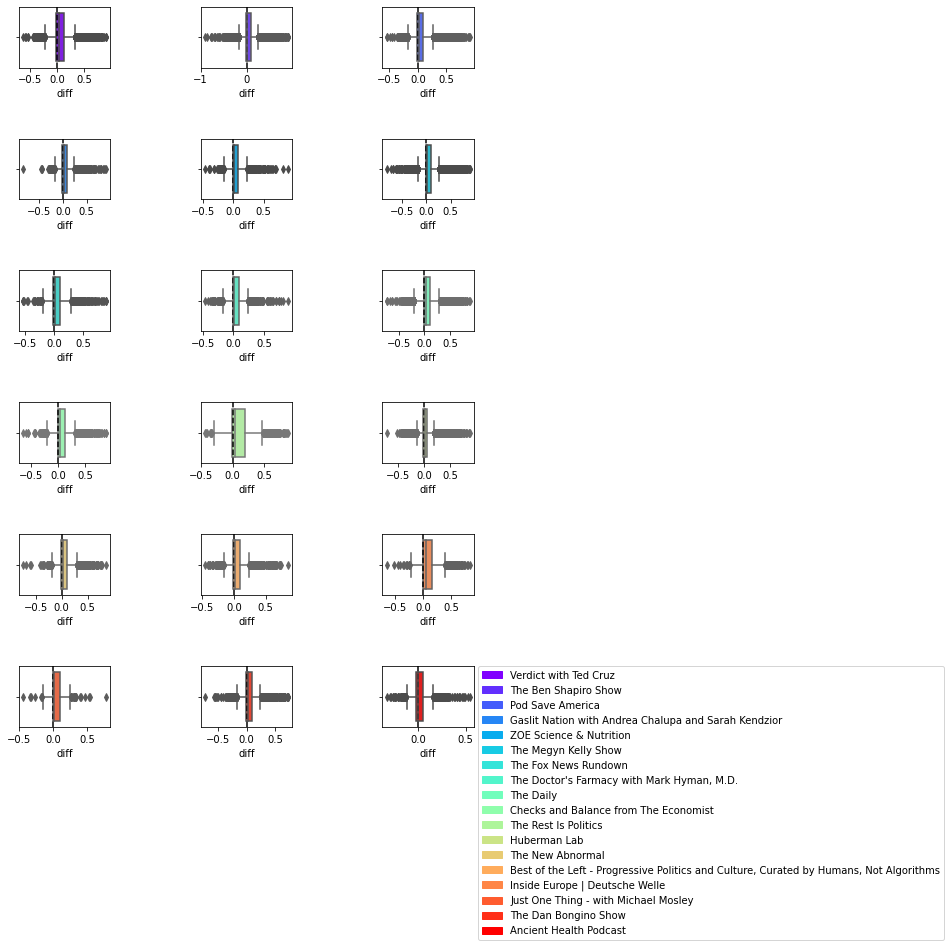